# Ender20 two-seed stability analysis

## tl;dr

Frozen-gate result: **`NOT_PROMOTION_ELIGIBLE`**. Calibration selection: **`none`**.
The equal-rank seed ensemble improved stability, but no predeclared benchmark
blend met every calibration requirement. No model was packaged or uploaded.


In [1]:
from pathlib import Path
import hashlib
import json
import pandas as pd
import matplotlib.pyplot as plt

RESULT_JSON = Path('results/two_seed_stability_result.json')
SUMMARY_CSV = Path('results/two_seed_stability_summary-489b334e7e75b86a124e.csv')
PER_ERA_CSV = Path('results/two_seed_stability_per_era-489b334e7e75b86a124e.csv')
EXPECTED_RESULT_SHA256 = '960b299f85bc68dfdb6c84a88d38008058b6f6c38aee8cfc0887850ed03bf95c'
EXPECTED_SUMMARY_SHA256 = '7ef041d7be6c4eb5974f17fd0f82ec68edb31d47a373bb43c71cf620d70c7997'
EXPECTED_PER_ERA_SHA256 = 'c946651ec54293645e75e0f46bfd45aea88781d3c5ffd151667b0cfe504b8dfa'

def sha256(path):
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

assert sha256(RESULT_JSON) == EXPECTED_RESULT_SHA256
assert sha256(SUMMARY_CSV) == EXPECTED_SUMMARY_SHA256
assert sha256(PER_ERA_CSV) == EXPECTED_PER_ERA_SHA256

result = json.loads(RESULT_JSON.read_text(encoding="utf-8"))
summary = pd.read_csv(SUMMARY_CSV)
per_era = pd.read_csv(PER_ERA_CSV, dtype={"era": str})

assert result["cohort"]["rows"] == 5_112_039
assert result["cohort"]["eras"] == 855
assert per_era["era"].nunique() == 855
print(result["state"], "| selected:", result["selected_candidate"])
print("generation:", result["generation_id"], "| output hashes verified")


NOT_PROMOTION_ELIGIBLE | selected: None
generation: 489b334e7e75b86a124e | output hashes verified


## Context & Methods

The original K64 TabM residual retained unique Ender20 signal but failed its
production stability gate. A first benchmark-blend experiment narrowly missed
its frozen Sharpe threshold. This final iteration trained only the predeclared
second model seed, ranked both seeds within each era, averaged them equally,
reranked the ensemble, and tested the same five benchmark weights.

The first 655 chronological OOF eras are calibration. The final 200 eras are a
locked holdout. Candidate selection uses calibration only; because none passed,
the holdout is context and cannot choose a substitute winner.

### Key Assumptions

- Both OOF artifacts are exact model predictions for the independently derived
  ID, era, target, and fold cohort and use the same residual-target semantics.
- The historical source manifest is only the immutable feature-store data
  anchor; current training code is anchored to the committed pre-training Git
  checkpoint recorded in the result receipt.
- Per-era Corr, BMC, benchmark similarity, Sharpe, and additive maximum drawdown
  are useful offline diagnostics, not guarantees of live performance.
- Seeds, blend weights, thresholds, split, and stop rule in `gate.md` were
  frozen before the second-seed model was trained or scored.


## Data

In [2]:
direct_inputs = []
for name, details in result["inputs"].items():
    if isinstance(details, dict) and "path" in details and "sha256" in details:
        direct_inputs.append({"input": name, "path": details["path"], "sha256": details["sha256"]})

display(pd.Series(result["cohort"], name="cohort"))
display(pd.DataFrame(direct_inputs))
display(pd.Series(result["inputs"]["frozen_source"], name="source anchors"))


calibration_eras         655
eras                     855
first_era               0371
first_holdout_era       1026
holdout_eras             200
last_era                1225
rows                 5112039
Name: cohort, dtype: object

,input,path,sha256
0,evaluator,numerai/agents/code/analysis/evaluate_ender20_...,851db9af3450207f5b1651b613acf6e8e6d4b1c23ebed3...
1,gate,numerai/agents/experiments/ender20_seed_ensemb...,3097219be90c4fb49d07a461c129e8121942e49a74d9af...
2,manifest,numerai/v5.3/target_ender_20_feature_store/man...,07eded145ab7249bfe3fa17cd109a343a9ac5cd9502750...
3,seed1337_predictions,numerai/agents/experiments/ender20_nn_architec...,196f56053eb23a04d32c80118dd90e99c41290c99cefcf...
4,seed1337_result,numerai/agents/experiments/ender20_nn_architec...,3c48bf7ebfbb75ceefb6b3eb8ff5b4171fb2066c13f115...
5,seed2027_config,numerai/agents/experiments/ender20_nn_architec...,3f952a926136f1d810fbf0b3cacb59e026b1156ddf3402...
6,seed2027_predictions,numerai/agents/experiments/ender20_nn_architec...,58027368888ba806383003acb8cdbcc6252223b0b75395...
7,seed2027_result,numerai/agents/experiments/ender20_nn_architec...,0fd6c896b6536ee5038ffec0884ebe3a7586bf9322028d...


historical_data_git_head             2447005b3f2af1fd45b883f2e63d1ebb80f75981
pretraining_git_commit               8964a1b51813a352a526fccd7270d23fed834d0d
source_manifest_sha256      2598382b910fcfe8c3f9adc0fce909cdbc8cadb69a4d36...
store_generation_id                          2d55564480dc4417b88b60d2fcda8bd4
Name: source anchors, dtype: str

## Results

In [3]:
columns = [
    "segment", "candidate", "bmc_mean", "bmc_sharpe",
    "bmc_max_drawdown", "corr_mean", "avg_corr_with_benchmark",
]
candidate_table = summary.loc[
    summary["candidate"].str.startswith("two_seed_hybrid_"), columns
].copy()
display(candidate_table.round(6).reset_index(drop=True))


,segment,candidate,bmc_mean,bmc_sharpe,bmc_max_drawdown,corr_mean,avg_corr_with_benchmark
0,calibration,two_seed_hybrid_w35,0.002787,0.483695,0.121619,0.037260,0.897152
1,calibration,two_seed_hybrid_w45,0.003797,0.529774,0.146806,0.035018,0.801181
2,calibration,two_seed_hybrid_w55,0.004763,0.559113,0.173424,0.032211,0.666471
3,calibration,two_seed_hybrid_w65,0.005555,0.579246,0.194913,0.028849,0.520850
4,calibration,two_seed_hybrid_w75,0.006199,0.598557,0.212911,0.025102,0.384813
5,holdout,two_seed_hybrid_w35,0.002588,0.554140,0.039911,0.022645,0.876357
6,holdout,two_seed_hybrid_w45,0.003457,0.630040,0.047186,0.020834,0.745352
7,holdout,two_seed_hybrid_w55,0.004217,0.671066,0.053276,0.018408,0.547910
8,holdout,two_seed_hybrid_w65,0.004739,0.692655,0.058556,0.015533,0.345336
9,holdout,two_seed_hybrid_w75,0.005091,0.712520,0.058279,0.012520,0.174338


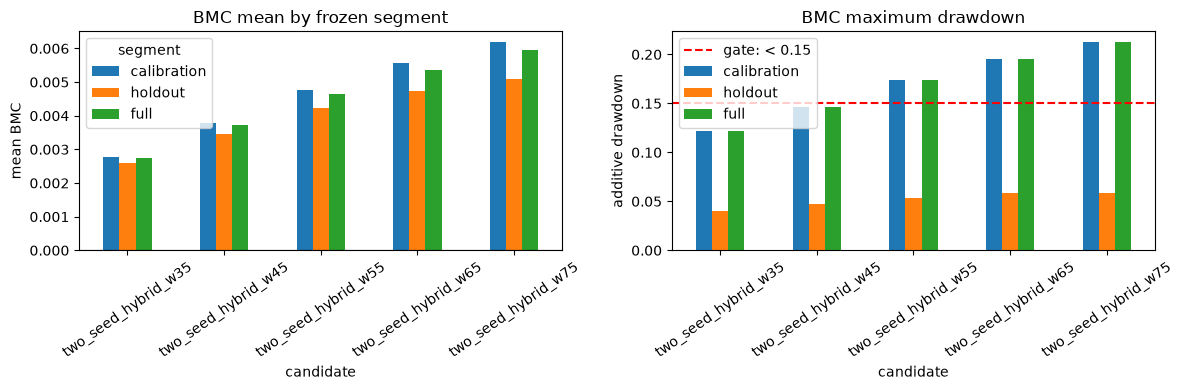

In [4]:
plot_data = candidate_table.pivot(
    index="candidate", columns="segment", values=["bmc_mean", "bmc_max_drawdown"]
)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_data["bmc_mean"][["calibration", "holdout", "full"]].plot.bar(
    ax=axes[0], title="BMC mean by frozen segment"
)
axes[0].axhline(0.0, color="black", linewidth=0.8)
axes[0].set_ylabel("mean BMC")
plot_data["bmc_max_drawdown"][["calibration", "holdout", "full"]].plot.bar(
    ax=axes[1], title="BMC maximum drawdown"
)
axes[1].axhline(0.15, color="red", linestyle="--", label="gate: < 0.15")
axes[1].set_ylabel("additive drawdown")
axes[1].legend()
for axis in axes:
    axis.tick_params(axis="x", rotation=35)
fig.tight_layout()
plt.show()


In [5]:
calibration = pd.DataFrame(result["calibration_candidates"]).T
calibration["failed_checks"] = calibration["checks"].map(
    lambda checks: ", ".join(name for name, passed in checks.items() if not passed) or "none"
)
display(calibration[["eligible", "failed_checks"]])

cal_summary = summary.loc[summary["segment"].eq("calibration")].set_index("candidate")
residual_bmc = cal_summary.loc["two_seed_residual", "bmc_mean"]
benchmark_corr = cal_summary.loc["benchmark_only", "corr_mean"]
near_misses = pd.DataFrame(
    {
        "observed_retention": [
            cal_summary.loc["two_seed_hybrid_w35", "bmc_mean"] / residual_bmc,
            cal_summary.loc["two_seed_hybrid_w45", "corr_mean"] / benchmark_corr,
        ],
        "required_retention": [0.40, 0.90],
    },
    index=["w35 residual BMC", "w45 benchmark Corr"],
)
display(near_misses.style.format("{:.2%}"))
print("Final state:", result["state"], "| promotion checks:", result["promotion_checks"])


,eligible,failed_checks
two_seed_hybrid_w35,False,residual_bmc_retention
two_seed_hybrid_w45,False,benchmark_corr_retention
two_seed_hybrid_w55,False,"benchmark_corr_retention, bmc_max_drawdown"
two_seed_hybrid_w65,False,"benchmark_corr_retention, bmc_max_drawdown"
two_seed_hybrid_w75,False,"benchmark_corr_retention, bmc_max_drawdown"


,observed_retention,required_retention
w35 residual BMC,38.47%,40.00%
w45 benchmark Corr,85.12%,90.00%


Final state: NOT_PROMOTION_ELIGIBLE | promotion checks: {}


## Takeaways

No frozen blend cleared calibration eligibility. Per the predeclared stop rule, this benchmark-blend line ends without another weight or seed search.

The two-seed residual was more stable than either seed alone, and the 35% blend
looked favorable on the locked holdout. Neither observation can override the
calibration gate: the 35% blend retained 38.47% of residual BMC against a 40%
minimum, while the 45% blend retained 85.12% of benchmark target Corr against a
90% minimum. The existing single-seed pickle remains experimental and should
not be uploaded as a production model.

The final 200 eras are formula-new but not fully data-new because prior research
already summarized recent performance for the residual reference. This is a
robustness check, not live validation, and offline metrics cannot prove future
returns or Numerai-hosted runtime compatibility.
